# SDSS vs Legacy vs Pipe3D: alignment and feature-space comparison

This notebook picks one random target from your local `manga_sdss_fits` directory that has SDSS, Legacy, and Pipe3D products for the same `plateifu`.

- SDSS FITS/JPEG: loaded from `sdss_cutouts`
- Legacy FITS/JPEG: loaded from `legacy_cutouts`
- Pipe3D FITS cube/maps: loaded from `manga-<plate>-<ifu>.Pipe3D.cube.fits.gz`

Use this to verify cross-survey alignment, inspect Pipe3D HDUs, and quickly load/display 2D maps or slices from 3D products.

In [8]:
# If needed, uncomment and run:
# %pip install astropy matplotlib pillow reproject

import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from astropy.io import fits
from astropy.wcs import FITSFixedWarning, WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from reproject import reproject_interp

warnings.filterwarnings("ignore", category=FITSFixedWarning)

In [9]:
data_root = Path("manga_sdss_fits")
if not data_root.exists():
    raise FileNotFoundError("Could not find 'manga_sdss_fits' in the current working directory.")

plateifu_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
if not plateifu_dirs:
    raise RuntimeError("No target directories found inside manga_sdss_fits.")


def build_pipe3d_path(target_path):
    plateifu_token = target_path.name.replace("_", "-")
    return target_path / f"manga-{plateifu_token}.Pipe3D.cube.fits.gz"


eligible_dirs = []
for candidate in plateifu_dirs:
    sdss_dir_candidate = candidate / "sdss_cutouts"
    legacy_dir_candidate = candidate / "legacy_cutouts"
    pipe3d_candidate = build_pipe3d_path(candidate)

    if sdss_dir_candidate.exists() and legacy_dir_candidate.exists() and pipe3d_candidate.exists():
        eligible_dirs.append(candidate)

if not eligible_dirs:
    raise RuntimeError("No targets found with SDSS + Legacy + Pipe3D data together.")

target_dir = random.choice(eligible_dirs)
plateifu = target_dir.name

sdss_dir = target_dir / "sdss_cutouts"
legacy_dir = target_dir / "legacy_cutouts"
pipe3d_path = build_pipe3d_path(target_dir)

sdss_meta_path = sdss_dir / "metadata.json"
legacy_meta_path = legacy_dir / "metadata.json"

if not sdss_meta_path.exists() or not legacy_meta_path.exists():
    raise RuntimeError(f"Missing metadata.json files for {plateifu}.")

sdss_meta = json.loads(sdss_meta_path.read_text())
legacy_meta = json.loads(legacy_meta_path.read_text())

ra = float(sdss_meta["ra_deg"])
dec = float(sdss_meta["dec_deg"])

print(f"Selected plateifu: {plateifu}")
print(f"RA, Dec = {ra:.6f}, {dec:.6f}")
print(f"Pipe3D cube: {pipe3d_path}")
print(f"Eligible targets with all three products: {len(eligible_dirs)}")

Selected plateifu: 8997_6103
RA, Dec = 169.378360, 51.966330
Pipe3D cube: manga_sdss_fits\8997_6103\manga-8997-6103.Pipe3D.cube.fits.gz
Eligible targets with all three products: 10243


In [10]:
def load_fits_data_and_wcs(path):
    with fits.open(path) as hdul:
        data = hdul[0].data.astype(float)
        base_wcs = WCS(hdul[0].header)
        # Prefer explicit celestial axes (RA/Dec), fallback to generic 2D.
        wcs = base_wcs.celestial if base_wcs.has_celestial else WCS(hdul[0].header, naxis=2)
    return data, wcs


def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def pick_jpeg_path(cutout_dir, prefix):
    meta_path = cutout_dir / "metadata.json"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        jpeg_name = meta.get("jpeg_file")
        if jpeg_name:
            p = cutout_dir / jpeg_name
            if p.exists():
                return p

    for p in sorted(cutout_dir.glob(f"{prefix}-*-color.jpg")):
        return p
    return None


def _sorted_numeric_header_items(header, prefixes=("DESC_", "NAME", "INDEX")):
    items = []
    for key in header.keys():
        for prefix in prefixes:
            if key.startswith(prefix):
                suffix = key[len(prefix):]
                if suffix.isdigit():
                    value = str(header.get(key, "")).strip()
                    if value:
                        items.append((int(suffix), key, value))
    items.sort(key=lambda t: t[0])
    return items


def inspect_pipe3d_hdus(pipe3d_fits_path, max_rows=40):
    rows = []
    with fits.open(pipe3d_fits_path) as hdul:
        for idx, hdu in enumerate(hdul):
            data = hdu.data
            shape = tuple(data.shape) if data is not None else None
            rows.append({
                "idx": idx,
                "name": hdu.name,
                "ndim": None if data is None else data.ndim,
                "shape": shape,
                "dtype": None if data is None else str(data.dtype),
                "bunit": hdu.header.get("BUNIT", ""),
                "n_maps": shape[0] if (shape is not None and len(shape) == 3) else None,
            })

    print(f"Pipe3D HDUs: {len(rows)}")
    print("idx  name                  ndim  shape                maps  dtype        bunit")
    print("---  --------------------  ----  -------------------  ----  -----------  ---------------")
    for row in rows[:max_rows]:
        name = str(row["name"])[:20]
        ndim = "-" if row["ndim"] is None else str(row["ndim"])
        shape = "-" if row["shape"] is None else str(row["shape"])[:19]
        n_maps = "-" if row["n_maps"] is None else str(row["n_maps"])
        dtype = "-" if row["dtype"] is None else row["dtype"][:11]
        bunit = row["bunit"][:15]
        print(f"{row['idx']:>3}  {name:<20}  {ndim:>4}  {shape:<19}  {n_maps:>4}  {dtype:<11}  {bunit}")

    if len(rows) > max_rows:
        print(f"... ({len(rows) - max_rows} more HDUs)")

    return rows


def resolve_pipe3d_hdu_index(pipe3d_fits_path, hdu):
    with fits.open(pipe3d_fits_path) as hdul:
        if isinstance(hdu, int):
            if not (0 <= hdu < len(hdul)):
                raise IndexError(f"HDU index {hdu} out of range [0, {len(hdul)-1}]")
            return hdu

        hdu_name = str(hdu).strip().upper()
        for idx, item in enumerate(hdul):
            if str(item.name).upper() == hdu_name:
                return idx

    raise KeyError(f"HDU '{hdu}' was not found by name.")


def list_pipe3d_maps(pipe3d_fits_path, hdu):
    hdu_index = resolve_pipe3d_hdu_index(pipe3d_fits_path, hdu)
    with fits.open(pipe3d_fits_path) as hdul:
        header = hdul[hdu_index].header
        data = hdul[hdu_index].data

    if data is None:
        raise ValueError(f"HDU {hdu_index} has no data payload.")

    if data.ndim != 3:
        print(f"HDU {hdu_index} is {data.ndim}D with shape {data.shape}; no per-slice map list.")
        return []

    descriptor_items = _sorted_numeric_header_items(header)
    if descriptor_items:
        print(f"Map descriptors for HDU {hdu_index} ({header.get('EXTNAME', '')}):")
        for map_idx, _, label in descriptor_items[: min(len(descriptor_items), data.shape[0])]:
            print(f"  {map_idx:>4}: {label}")
    else:
        print(f"No descriptor keywords found in HDU {hdu_index}; using numeric map indices only.")

    return descriptor_items


def resolve_pipe3d_map_index(header, map_ref, n_maps):
    if isinstance(map_ref, int):
        if 0 <= map_ref < n_maps:
            return map_ref
        raise IndexError(f"map index {map_ref} out of range [0, {n_maps - 1}]")

    map_ref = str(map_ref).strip().lower()
    descriptor_items = _sorted_numeric_header_items(header)
    candidates = [i for i, _, label in descriptor_items if map_ref in label.lower()]
    if not candidates:
        raise KeyError(f"No map label contains '{map_ref}' in this HDU.")
    if len(candidates) > 1:
        print(f"Multiple matches for '{map_ref}'; using first: {candidates[0]}")
    return candidates[0]


def load_pipe3d_hdu(pipe3d_fits_path, hdu=1, map_ref=None):
    hdu_index = resolve_pipe3d_hdu_index(pipe3d_fits_path, hdu)

    with fits.open(pipe3d_fits_path) as hdul:
        hdu_obj = hdul[hdu_index]
        data = None if hdu_obj.data is None else np.array(hdu_obj.data, dtype=float)
        header = hdu_obj.header.copy()

        if data is None:
            raise ValueError(f"HDU {hdu_index} has no data payload.")

        selected_map_idx = None
        selected_map_label = None
        if data.ndim == 3:
            map_idx = 0 if map_ref is None else resolve_pipe3d_map_index(header, map_ref, data.shape[0])
            data = data[map_idx]
            selected_map_idx = map_idx

            descriptor_items = {i: label for i, _, label in _sorted_numeric_header_items(header)}
            selected_map_label = descriptor_items.get(map_idx, f"map {map_idx}")

        # Pipe3D science HDUs often do not include RA/Dec WCS directly.
        # Try selected HDU first, then ORG_HDR, then any HDU with celestial WCS.
        wcs_2d = None
        wcs_source = None
        candidate_indices = [hdu_index, 0] + [i for i in range(len(hdul)) if i not in (hdu_index, 0)]
        for idx in candidate_indices:
            cand_wcs = WCS(hdul[idx].header)
            if cand_wcs.has_celestial:
                wcs_2d = cand_wcs.celestial
                wcs_source = f"{idx}:{hdul[idx].name}"
                break

    if wcs_2d is None:
        raise ValueError(
            "Could not find celestial WCS in Pipe3D file. "
            "Cannot reproject to Legacy without RA/Dec axes."
        )

    print(f"Pipe3D spatial WCS source: {wcs_source}")
    return data, header, wcs_2d, hdu_index, selected_map_idx, selected_map_label


def choose_pipe3d_alignment_map(pipe3d_fits_path):
    # Science-first default: SSP map 0 (pseudo V-band), not utility masks.
    with fits.open(pipe3d_fits_path) as hdul:
        ssp_idx = None
        for idx, hdu in enumerate(hdul):
            if str(hdu.name).upper() == "SSP":
                ssp_idx = idx
                break
        if ssp_idx is not None and hdul[ssp_idx].data is not None and hdul[ssp_idx].data.ndim == 3:
            return ssp_idx, 0, hdul[ssp_idx].header.get("DESC_0", "pseudo V-band map")

        for idx, hdu in enumerate(hdul[1:], start=1):
            data = hdu.data
            if data is None:
                continue
            if getattr(data, "ndim", 0) == 3:
                return idx, 0, f"{hdu.name} map 0"
            if getattr(data, "ndim", 0) == 2:
                return idx, None, f"{hdu.name}"

    raise RuntimeError("Could not find a usable Pipe3D map for alignment checks.")


def peek_pipe3d_hdu(pipe3d_fits_path, hdu=1, n_values=8):
    hdu_index = resolve_pipe3d_hdu_index(pipe3d_fits_path, hdu)
    with fits.open(pipe3d_fits_path) as hdul:
        hdu_obj = hdul[hdu_index]
        data = hdu_obj.data
        header = hdu_obj.header

    print(f"HDU {hdu_index}: {hdu_obj.name}")
    if data is None:
        print("  No data payload.")
        return

    print(f"  shape={data.shape}, ndim={data.ndim}, dtype={data.dtype}, bunit={header.get('BUNIT', '')}")

    finite = np.asarray(data[np.isfinite(data)], dtype=float) if np.size(data) else np.array([])
    if finite.size:
        q = np.nanpercentile(finite, [0, 1, 50, 99, 100])
        print(f"  value percentiles [0,1,50,99,100] = {q}")

    flat = np.ravel(data)
    sample = flat[: min(n_values, flat.size)]
    print(f"  first {sample.size} values: {sample}")

    if data.ndim == 3:
        descriptors = _sorted_numeric_header_items(header)
        if descriptors:
            print("  map descriptors (first 20):")
            for map_idx, _, label in descriptors[:20]:
                print(f"    {map_idx:>4}: {label}")


plateifu_hyphen = plateifu.replace("_", "-")

sdss_r_path = first_existing([
    sdss_dir / f"sdss-{plateifu}-r.fits",
    sdss_dir / f"sdss-{plateifu_hyphen}-r.fits",
])
legacy_r_path = first_existing([
    legacy_dir / f"legacy-{plateifu}-r.fits",
    legacy_dir / f"legacy-{plateifu_hyphen}-r.fits",
])

sdss_jpeg_path = pick_jpeg_path(sdss_dir, "sdss")
legacy_jpeg_path = pick_jpeg_path(legacy_dir, "legacy")

required_paths = [sdss_r_path, legacy_r_path, sdss_jpeg_path, legacy_jpeg_path, pipe3d_path]
if any(p is None for p in required_paths) or not pipe3d_path.exists():
    debug_files = {
        "sdss_cutouts": [p.name for p in sorted(sdss_dir.glob("*"))],
        "legacy_cutouts": [p.name for p in sorted(legacy_dir.glob("*"))],
        "target_root": [p.name for p in sorted(target_dir.glob("*"))],
    }
    raise FileNotFoundError(
        "Could not resolve expected SDSS/Legacy or Pipe3D files.\n"
        f"plateifu folder: {plateifu}\n"
        f"Available files: {json.dumps(debug_files, indent=2)}"
    )

sdss_data, sdss_wcs = load_fits_data_and_wcs(sdss_r_path)
legacy_data, legacy_wcs = load_fits_data_and_wcs(legacy_r_path)

sdss_data_display, _ = reproject_interp((sdss_data, sdss_wcs), legacy_wcs, shape_out=legacy_data.shape)

pipe3d_map_hdu, pipe3d_map_index, pipe3d_map_label = choose_pipe3d_alignment_map(pipe3d_path)
pipe3d_map_data, pipe3d_map_header, pipe3d_map_wcs, _, _, _ = load_pipe3d_hdu(
    pipe3d_path,
    hdu=pipe3d_map_hdu,
    map_ref=pipe3d_map_index,
)

print(
    f"WCS dims (pipe in/out): {pipe3d_map_wcs.pixel_n_dim}/{pipe3d_map_wcs.world_n_dim} -> "
    f"{legacy_wcs.pixel_n_dim}/{legacy_wcs.world_n_dim}"
)
print(
    "WCS celestial (pipe/out): "
    f"{pipe3d_map_wcs.has_celestial}/{legacy_wcs.has_celestial}"
)
pipe3d_on_legacy, _ = reproject_interp((pipe3d_map_data, pipe3d_map_wcs), legacy_wcs, shape_out=legacy_data.shape)

sdss_jpeg = np.array(Image.open(sdss_jpeg_path).convert("RGB"))
legacy_jpeg = np.array(Image.open(legacy_jpeg_path).convert("RGB"))

print("SDSS r FITS:", sdss_r_path)
print("Legacy r FITS:", legacy_r_path)
print("Pipe3D cube:", pipe3d_path)
print(f"Pipe3D alignment selection: HDU {pipe3d_map_hdu}, map {pipe3d_map_index}, label='{pipe3d_map_label}'")
print("SDSS JPEG:", sdss_jpeg_path)
print("Legacy JPEG:", legacy_jpeg_path)

print("\nSDSS FITS shape:", sdss_data.shape)
print("Legacy FITS shape:", legacy_data.shape)
print("Pipe3D map shape:", pipe3d_map_data.shape)
print("Pipe3D map reprojected shape:", pipe3d_on_legacy.shape)
print("SDSS JPEG shape:", sdss_jpeg.shape)
print("Legacy JPEG shape:", legacy_jpeg.shape)

if "scale_arcsec_per_px" in sdss_meta:
    print(f"SDSS metadata scale: {sdss_meta['scale_arcsec_per_px']} arcsec/pixel")
if "size_px" in sdss_meta:
    print(f"SDSS metadata size:  {sdss_meta['size_px']} px")
if "size_px" in legacy_meta:
    print(f"Legacy metadata size: {legacy_meta['size_px']} px")

Pipe3D spatial WCS source: 0:ORG_HDR
WCS dims (pipe in/out): 2/2 -> 2/2
WCS celestial (pipe/out): True/True
SDSS r FITS: manga_sdss_fits\8997_6103\sdss_cutouts\sdss-8997-6103-r.fits
Legacy r FITS: manga_sdss_fits\8997_6103\legacy_cutouts\legacy-8997-6103-r.fits
Pipe3D cube: manga_sdss_fits\8997_6103\manga-8997-6103.Pipe3D.cube.fits.gz
Pipe3D alignment selection: HDU 1, map 0, label='pseudo V-band map'
SDSS JPEG: manga_sdss_fits\8997_6103\sdss_cutouts\sdss-8997-6103-color.jpg
Legacy JPEG: manga_sdss_fits\8997_6103\legacy_cutouts\legacy-8997-6103-color.jpg

SDSS FITS shape: (196, 196)
Legacy FITS shape: (198, 198)
Pipe3D map shape: (54, 54)
Pipe3D map reprojected shape: (198, 198)
SDSS JPEG shape: (196, 196, 3)
Legacy JPEG shape: (198, 198, 3)
SDSS metadata scale: 0.198 arcsec/pixel
SDSS metadata size:  196 px
Legacy metadata size: 198 px


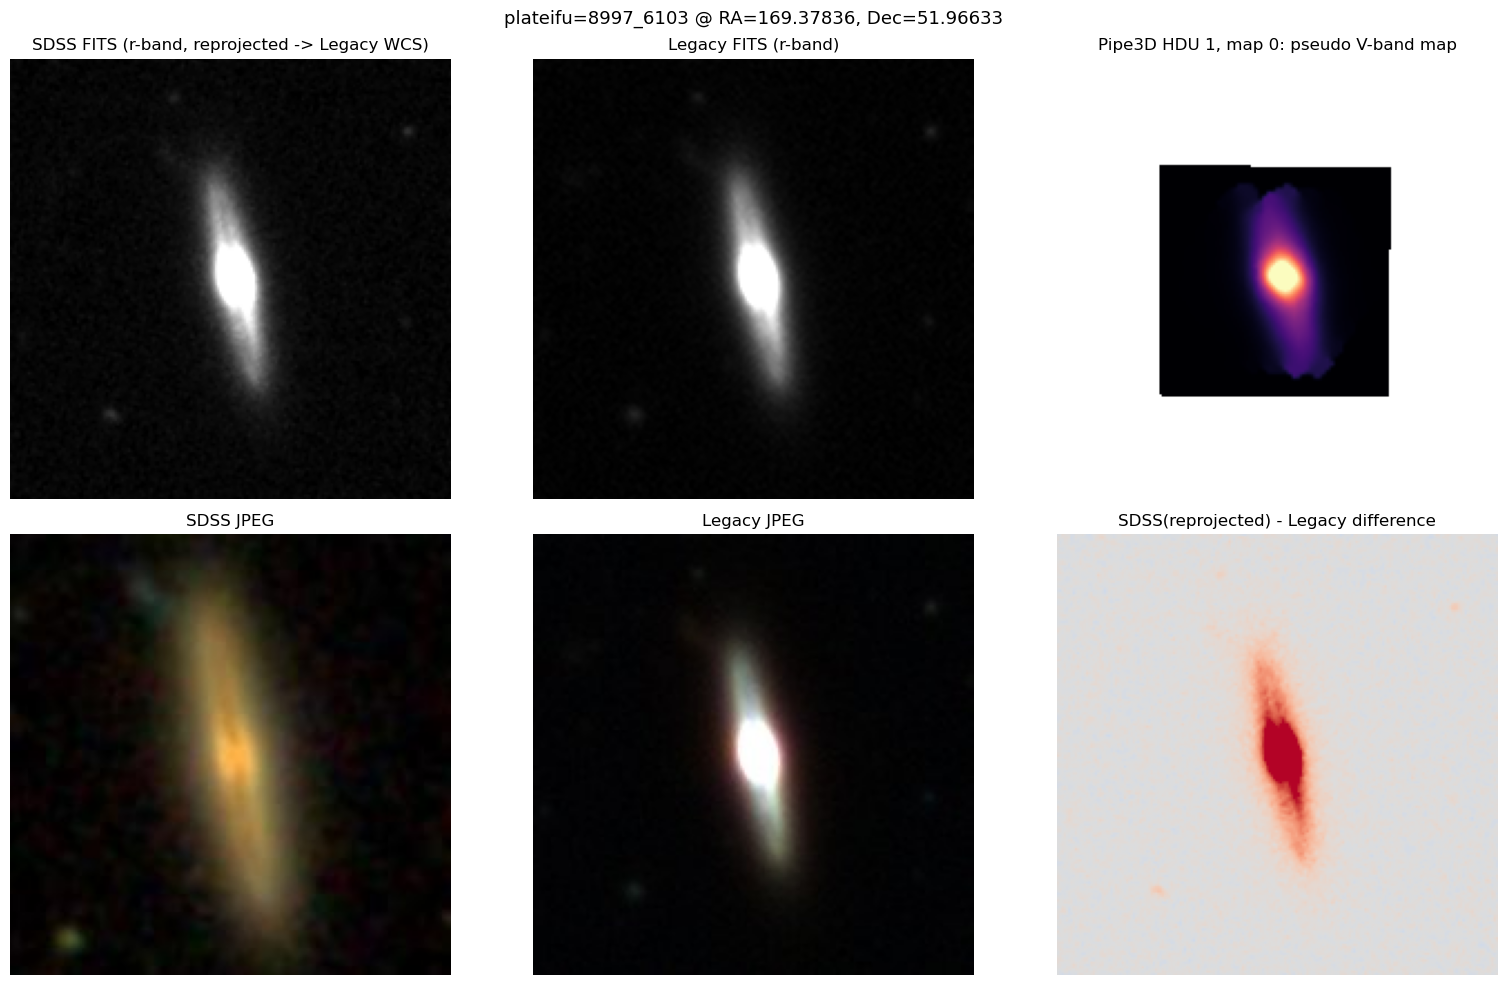

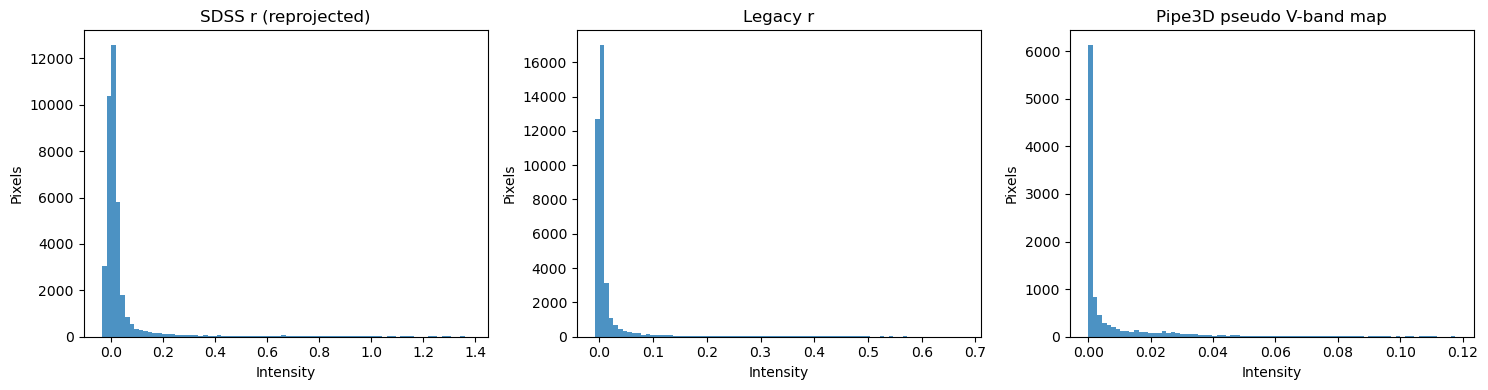

In [11]:
def robust_limits(data, lo=1, hi=99):
    vals = data[np.isfinite(data)]
    if vals.size == 0:
        return 0, 1
    return np.percentile(vals, [lo, hi])


sdss_vmin, sdss_vmax = robust_limits(sdss_data_display)
legacy_vmin, legacy_vmax = robust_limits(legacy_data)
pipe_vmin, pipe_vmax = robust_limits(pipe3d_on_legacy)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(sdss_data_display, origin="lower", cmap="gray", vmin=sdss_vmin, vmax=sdss_vmax)
axes[0, 0].set_title("SDSS FITS (r-band, reprojected -> Legacy WCS)")
axes[0, 0].axis("off")

axes[0, 1].imshow(legacy_data, origin="lower", cmap="gray", vmin=legacy_vmin, vmax=legacy_vmax)
axes[0, 1].set_title("Legacy FITS (r-band)")
axes[0, 1].axis("off")

axes[0, 2].imshow(pipe3d_on_legacy, origin="lower", cmap="magma", vmin=pipe_vmin, vmax=pipe_vmax)
axes[0, 2].set_title(f"Pipe3D HDU {pipe3d_map_hdu}, map {pipe3d_map_index}: {pipe3d_map_label}")
axes[0, 2].axis("off")

axes[1, 0].imshow(sdss_jpeg)
axes[1, 0].set_title("SDSS JPEG")
axes[1, 0].axis("off")

axes[1, 1].imshow(legacy_jpeg)
axes[1, 1].set_title("Legacy JPEG")
axes[1, 1].axis("off")

alignment_delta = sdss_data_display - legacy_data
delta_v = np.nanpercentile(np.abs(alignment_delta[np.isfinite(alignment_delta)]), 99)
axes[1, 2].imshow(alignment_delta, origin="lower", cmap="coolwarm", vmin=-delta_v, vmax=delta_v)
axes[1, 2].set_title("SDSS(reprojected) - Legacy difference")
axes[1, 2].axis("off")

fig.suptitle(f"plateifu={plateifu} @ RA={ra:.5f}, Dec={dec:.5f}", fontsize=13)
plt.tight_layout()
plt.show()

# A compact feature-space view across matched grids.
fig, h_axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arr, label in [
    (h_axes[0], sdss_data_display, "SDSS r (reprojected)"),
    (h_axes[1], legacy_data, "Legacy r"),
    (h_axes[2], pipe3d_on_legacy, f"Pipe3D {pipe3d_map_label}"),
]:
    vals = arr[np.isfinite(arr)]
    if vals.size:
        lo, hi = np.percentile(vals, [1, 99])
        vals = vals[(vals >= lo) & (vals <= hi)]
        ax.hist(vals, bins=80, alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Pixels")

plt.tight_layout()
plt.show()

In [12]:
# Optional: quick sanity checks about pixel scales from WCS
sdss_scale_measured = proj_plane_pixel_scales(sdss_wcs)[0] * 3600
legacy_scale_measured = proj_plane_pixel_scales(legacy_wcs)[0] * 3600
pipe_scale_measured = proj_plane_pixel_scales(pipe3d_map_wcs)[0] * 3600

print(f"Measured SDSS cutout scale:   {sdss_scale_measured:.4f} arcsec/pixel")
print(f"Measured Legacy cutout scale: {legacy_scale_measured:.4f} arcsec/pixel")
print(f"Measured Pipe3D map scale:    {pipe_scale_measured:.4f} arcsec/pixel")


# --- Pipe3D feature-space and map access helpers ---
pipe3d_hdu_summary = inspect_pipe3d_hdus(pipe3d_path, max_rows=50)


def show_pipe3d_map(pipe3d_fits_path, hdu=1, map_ref=None, cmap="magma"):
    """
    Display a selected Pipe3D map.

    Parameters
    ----------
    hdu : int or str
        HDU index or HDU name, e.g. 1 or "SSP".
    map_ref : int or str or None
        For 3D HDUs, choose the map by index (e.g. 0) or partial label match
        (e.g. "pseudo V-band", "Ha", "vel").
        If None and HDU is 3D, map 0 is used.
    """
    data, header, _, hdu_index, map_idx, map_label = load_pipe3d_hdu(
        pipe3d_fits_path,
        hdu=hdu,
        map_ref=map_ref,
    )

    if data.ndim != 2:
        raise ValueError(f"Selected data is {data.ndim}D with shape {data.shape}; expected a 2D map.")

    vmin, vmax = robust_limits(data)
    plt.figure(figsize=(6, 6))
    plt.imshow(data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    label = map_label if map_label is not None else "2D image"
    idx_txt = "-" if map_idx is None else map_idx
    plt.title(f"HDU {hdu_index}, map {idx_txt}: {label}")
    plt.colorbar(label=header.get("BUNIT", "value"))
    plt.axis("off")
    plt.show()


def show_pipe3d_reprojected_map(pipe3d_fits_path, hdu=1, map_ref=None, cmap="magma"):
    """Display a selected Pipe3D map reprojected onto Legacy WCS for alignment checks."""
    data, header, map_wcs, hdu_index, map_idx, map_label = load_pipe3d_hdu(pipe3d_fits_path, hdu=hdu, map_ref=map_ref)
    reproj, _ = reproject_interp((data, map_wcs), legacy_wcs, shape_out=legacy_data.shape)
    vmin, vmax = robust_limits(reproj)

    plt.figure(figsize=(6, 6))
    plt.imshow(reproj, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    label = map_label if map_label is not None else "2D image"
    idx_txt = "-" if map_idx is None else map_idx
    plt.title(f"Reprojected: HDU {hdu_index}, map {idx_txt}: {label}")
    plt.colorbar(label=header.get("BUNIT", "value"))
    plt.axis("off")
    plt.show()


# Quick helpers for exploring what is available in one HDU:
# peek_pipe3d_hdu(pipe3d_path, hdu="SSP")
# list_pipe3d_maps(pipe3d_path, hdu="SSP")

# Final usage patterns (index or name):
# show_pipe3d_map(pipe3d_path, hdu="SSP", map_ref=0)
# show_pipe3d_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")
# show_pipe3d_reprojected_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")


Measured SDSS cutout scale:   0.3961 arcsec/pixel
Measured Legacy cutout scale: 0.2620 arcsec/pixel
Measured Pipe3D map scale:    0.5000 arcsec/pixel
Pipe3D HDUs: 9
idx  name                  ndim  shape                maps  dtype        bunit
---  --------------------  ----  -------------------  ----  -----------  ---------------
  0  ORG_HDR                  -  -                       -  -            1E-16 erg/s/cm^
  1  SSP                      3  (21, 54, 54)           21  >f8          
  2  SFH                      3  (319, 54, 54)         319  >f8          
  3  INDICES                  3  (18, 54, 54)           18  >f8          
  4  ELINES                   3  (11, 54, 54)           11  >f8          
  5  FLUX_ELINES              3  (456, 54, 54)         456  >f8          
  6  FLUX_ELINES_LONG         3  (1536, 54, 54)       1536  >f8          
  7  GAIA_MASK                2  (54, 54)                -  >f8          
  8  SELECT_REG               2  (54, 54)                -  

In [13]:
# Quick helpers for exploring what is available in one HDU:
peek_pipe3d_hdu(pipe3d_path, hdu="SSP")
list_pipe3d_maps(pipe3d_path, hdu="SSP")

# Final usage patterns (index or name):
# show_pipe3d_map(pipe3d_path, hdu="SSP", map_ref=0)
# show_pipe3d_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")
# show_pipe3d_reprojected_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")

HDU 1: SSP
  shape=(21, 54, 54), ndim=3, dtype=>f8, bunit=
  value percentiles [0,1,50,99,100] = [-1.80109775e+00 -3.52898270e-01  0.00000000e+00  8.27393262e+03
  8.66189551e+03]
  first 8 values: [0. 0. 0. 0. 0. 0. 0. 0.]
  map descriptors (first 20):
       0: pseudo V-band map
       1: continuum segmentation file
       2: continuum dezonification file
       3: median intensity flux within the wavelength range
       4: StdDev median intensity flux within the wavelength range
       5: luminosity weighted age of the stellar population
       6: mass weighted age of the stellar population
       7: error of the age of the stellar population
       8: luminosity weighted metallicity of the stellar population
       9: mass weighted metallicity of the stellar population
      10: error metallicity of the stellar population
      11: average dust attnuation of the stellar population
      12: error of the average dust attnuation of the stellar population
      13: velocity of the ste

[(0, 'DESC_0', 'pseudo V-band map'),
 (1, 'DESC_1', 'continuum segmentation file'),
 (2, 'DESC_2', 'continuum dezonification file'),
 (3, 'DESC_3', 'median intensity flux within the wavelength range'),
 (4, 'DESC_4', 'StdDev median intensity flux within the wavelength range'),
 (5, 'DESC_5', 'luminosity weighted age of the stellar population'),
 (6, 'DESC_6', 'mass weighted age of the stellar population'),
 (7, 'DESC_7', 'error of the age of the stellar population'),
 (8, 'DESC_8', 'luminosity weighted metallicity of the stellar population'),
 (9, 'DESC_9', 'mass weighted metallicity of the stellar population'),
 (10, 'DESC_10', 'error metallicity of the stellar population'),
 (11, 'DESC_11', 'average dust attnuation of the stellar population'),
 (12,
  'DESC_12',
  'error of the average dust attnuation of the stellar population'),
 (13, 'DESC_13', 'velocity of the stellar population'),
 (14, 'DESC_14', 'error in the velocity of the stellar population'),
 (15, 'DESC_15', 'velocity disp

Pipe3D spatial WCS source: 0:ORG_HDR


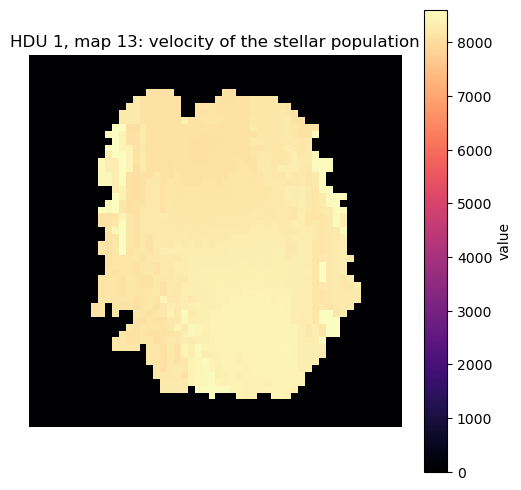

In [ ]:
show_pipe3d_map(pipe3d_path, hdu="SSP", map_ref=13)

In [28]:
list_pipe3d_maps(pipe3d_path, hdu="INDICES")

Map descriptors for HDU 3 (INDICES):
     0: Hd
     1: Hb
     2: Mgb
     3: Fe5270
     4: Fe5335
     5: D4000
     6: Hdmod
     7: Hg
     8: SN
     9: e_Hd
    10: e_Hb
    11: e_Mgb
    12: e_Fe5270
    13: e_Fe5335
    14: e_D4000
    15: e_Hdmod
    16: e_Hg
    17: e_SN


[(0, 'INDEX0', 'Hd'),
 (1, 'INDEX1', 'Hb'),
 (2, 'INDEX2', 'Mgb'),
 (3, 'INDEX3', 'Fe5270'),
 (4, 'INDEX4', 'Fe5335'),
 (5, 'INDEX5', 'D4000'),
 (6, 'INDEX6', 'Hdmod'),
 (7, 'INDEX7', 'Hg'),
 (8, 'INDEX8', 'SN'),
 (9, 'INDEX9', 'e_Hd'),
 (10, 'INDEX10', 'e_Hb'),
 (11, 'INDEX11', 'e_Mgb'),
 (12, 'INDEX12', 'e_Fe5270'),
 (13, 'INDEX13', 'e_Fe5335'),
 (14, 'INDEX14', 'e_D4000'),
 (15, 'INDEX15', 'e_Hdmod'),
 (16, 'INDEX16', 'e_Hg'),
 (17, 'INDEX17', 'e_SN')]

Pipe3D spatial WCS source: 0:ORG_HDR


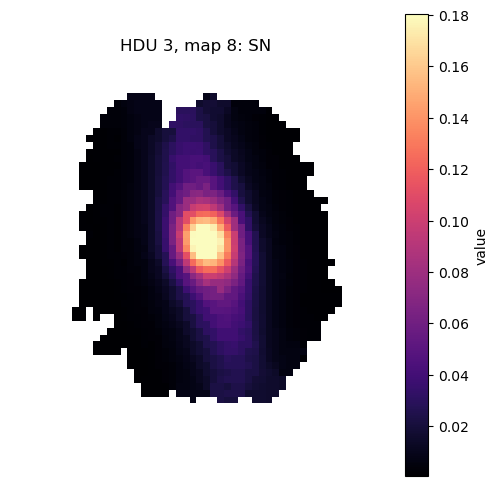

In [ ]:
show_pipe3d_map(pipe3d_path, hdu="INDICES", map_ref=)

In [35]:
list_pipe3d_maps(pipe3d_path, hdu="FLUX_ELINES")

Map descriptors for HDU 5 (FLUX_ELINES):
     0: flux [OII]3727
     1: flux H12
     2: flux H11
     3: flux H10
     4: flux HeI3819
     5: flux H9
     6: flux [NeIII]
     7: flux H8
     8: flux [NeIII]
     9: flux He
    10: flux HeI4026
    11: flux [SII]
    12: flux [SII]
    13: flux Hd
    14: flux [FeII]
    15: flux [FeII]
    16: flux [FeII]
    17: flux Hg
    18: flux [OIII]4363
    19: flux [FeII]
    20: flux [FeII]
    21: flux HeI4471
    22: flux [FeIII]
    23: flux HeII
    24: flux HeI4713
    25: flux HeI4922
    26: flux [OIII]5007
    27: flux [OIII]4959
    28: flux Hb
    29: flux [FeII]
    30: flux [FeII]
    31: flux [FeII]
    32: flux [FeII]
    33: flux [NI]
    34: flux [FeII]
    35: flux [ClIII]
    36: flux [ClIII]
    37: flux OI
    38: flux [OI]
    39: flux [NII]
    40: flux HeI5876
    41: flux [OI]
    42: flux [SIII]
    43: flux SiII
    44: flux [OI]
    45: flux Ha
    46: flux [NII]6584
    47: flux [NII]6548
    48: flux HeI6678
  

[(0, 'NAME0', 'flux [OII]3727'),
 (1, 'NAME1', 'flux H12'),
 (2, 'NAME2', 'flux H11'),
 (3, 'NAME3', 'flux H10'),
 (4, 'NAME4', 'flux HeI3819'),
 (5, 'NAME5', 'flux H9'),
 (6, 'NAME6', 'flux [NeIII]'),
 (7, 'NAME7', 'flux H8'),
 (8, 'NAME8', 'flux [NeIII]'),
 (9, 'NAME9', 'flux He'),
 (10, 'NAME10', 'flux HeI4026'),
 (11, 'NAME11', 'flux [SII]'),
 (12, 'NAME12', 'flux [SII]'),
 (13, 'NAME13', 'flux Hd'),
 (14, 'NAME14', 'flux [FeII]'),
 (15, 'NAME15', 'flux [FeII]'),
 (16, 'NAME16', 'flux [FeII]'),
 (17, 'NAME17', 'flux Hg'),
 (18, 'NAME18', 'flux [OIII]4363'),
 (19, 'NAME19', 'flux [FeII]'),
 (20, 'NAME20', 'flux [FeII]'),
 (21, 'NAME21', 'flux HeI4471'),
 (22, 'NAME22', 'flux [FeIII]'),
 (23, 'NAME23', 'flux HeII'),
 (24, 'NAME24', 'flux HeI4713'),
 (25, 'NAME25', 'flux HeI4922'),
 (26, 'NAME26', 'flux [OIII]5007'),
 (27, 'NAME27', 'flux [OIII]4959'),
 (28, 'NAME28', 'flux Hb'),
 (29, 'NAME29', 'flux [FeII]'),
 (30, 'NAME30', 'flux [FeII]'),
 (31, 'NAME31', 'flux [FeII]'),
 (32, 'NAM

Multiple matches for 'ha'; using first: 45
Pipe3D spatial WCS source: 0:ORG_HDR


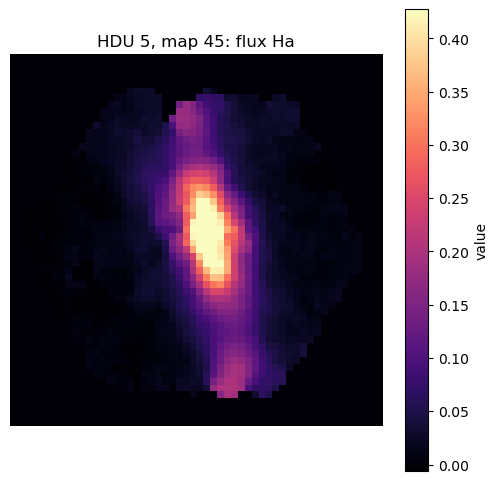

In [26]:
show_pipe3d_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")

Multiple matches for 'ha'; using first: 45
Pipe3D spatial WCS source: 0:ORG_HDR


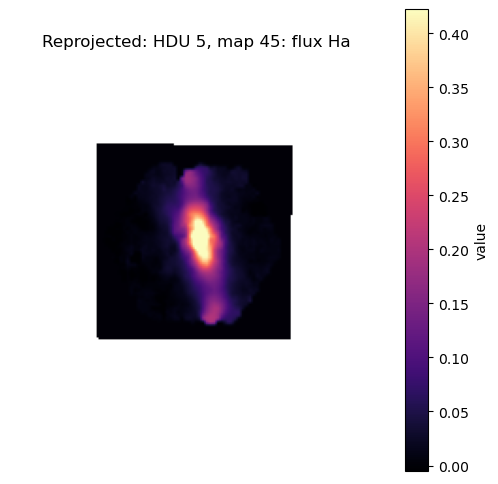

In [27]:
show_pipe3d_reprojected_map(pipe3d_path, hdu="FLUX_ELINES", map_ref="Ha")